In [5]:
from google.colab import files

uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded")

Libraries Loaded


In [6]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (577347, 12)
Test Shape  : (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [7]:
def reduce_memory(df):

    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:

        col_type = df[col].dtype

        if col_type != object:

            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            else:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2

    print(
        f"Memory Usage: {start_mem:.2f} MB -> {end_mem:.2f} MB"
    )

    return df

In [8]:
train = reduce_memory(train)
test = reduce_memory(test)

Memory Usage: 52.86 MB -> 33.04 MB
Memory Usage: 20.77 MB -> 12.27 MB


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int32  
 1   alpha              577347 non-null  float32
 2   delta              577347 non-null  float32
 3   u                  577347 non-null  float32
 4   g                  577347 non-null  float32
 5   r                  577347 non-null  float32
 6   i                  577347 non-null  float32
 7   z                  577347 non-null  float32
 8   redshift           577347 non-null  float32
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float32(8), int32(1), object(3)
memory usage: 33.0+ MB


In [10]:
missing = pd.DataFrame({
    "Missing": train.isnull().sum(),
    "Percent": train.isnull().mean()*100
})

missing.sort_values(
    "Percent",
    ascending=False
)

,Missing,Percent
id,0,0.0
alpha,0,0.0
delta,0,0.0
u,0,0.0
g,0,0.0
r,0,0.0
i,0,0.0
z,0,0.0
redshift,0,0.0
spectral_type,0,0.0


In [11]:
print(
    "Duplicate Rows:",
    train.duplicated().sum()
)

Duplicate Rows: 0


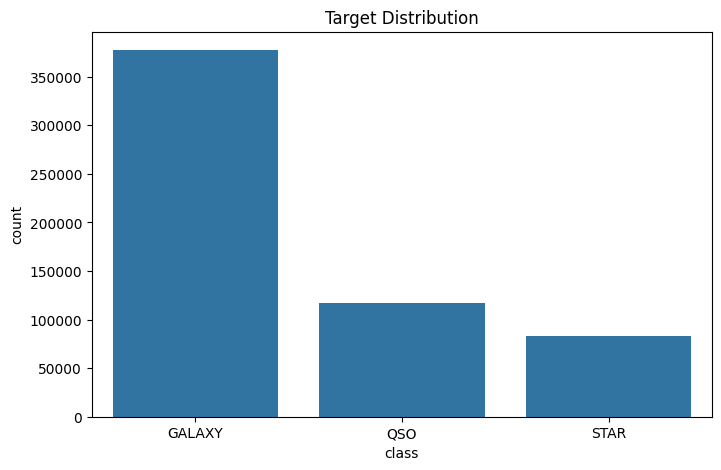

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="class"
)

plt.title("Target Distribution")

plt.show()

In [13]:
num_cols = [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
]

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616653,96.230423,0.011684,132.161499,188.681473,231.829689,359.999817
delta,577347.0,21.834658,18.931969,-17.966988,2.474097,21.484411,36.988310,79.158325
u,577347.0,22.441927,2.017941,-0.139225,20.977090,22.570223,23.869102,28.253263
g,577347.0,21.007273,1.795269,13.535483,19.865005,21.467819,22.292715,27.620207
r,577347.0,19.962809,1.648817,12.579407,18.820670,20.431152,21.164096,25.254499
i,577347.0,19.378908,1.579872,11.962782,18.306820,19.631641,20.608191,27.910852
z,577347.0,19.041134,1.584124,11.682803,17.973192,19.188599,20.162112,26.826866
redshift,577347.0,0.723135,0.809953,-0.009970,0.181052,0.497525,0.881390,7.010780


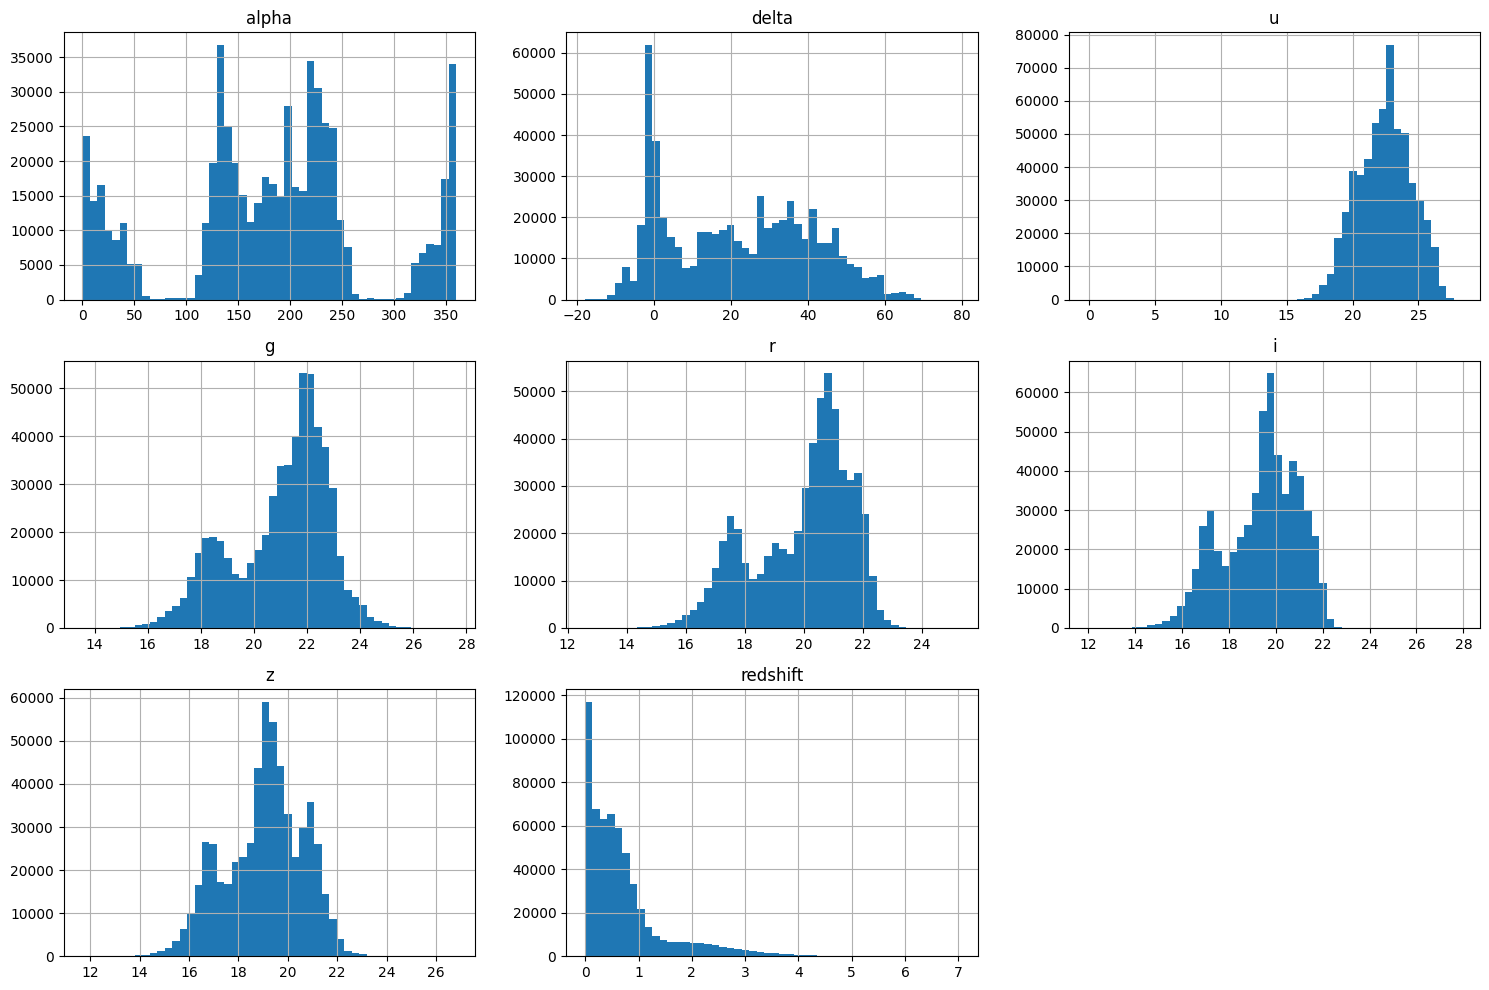

In [14]:
train[num_cols].hist(
    figsize=(15,10),
    bins=50
)

plt.tight_layout()
plt.show()

In [15]:
cat_cols = [
    "spectral_type",
    "galaxy_population"
]

for col in cat_cols:

    print("\n")
    print(col)

    print(
        train[col].value_counts()
    )



spectral_type
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64


galaxy_population
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64


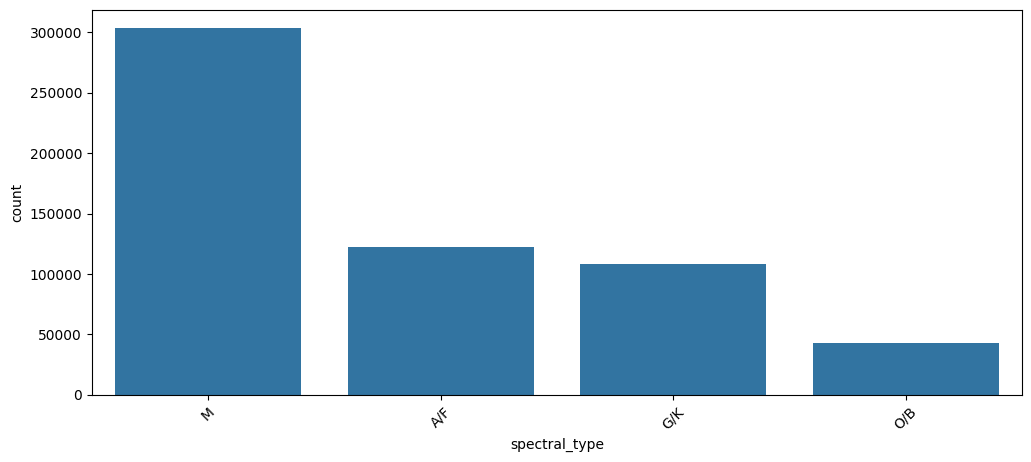

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=train,
    x="spectral_type",
    order=train["spectral_type"]
    .value_counts()
    .index
)

plt.xticks(rotation=45)

plt.show()

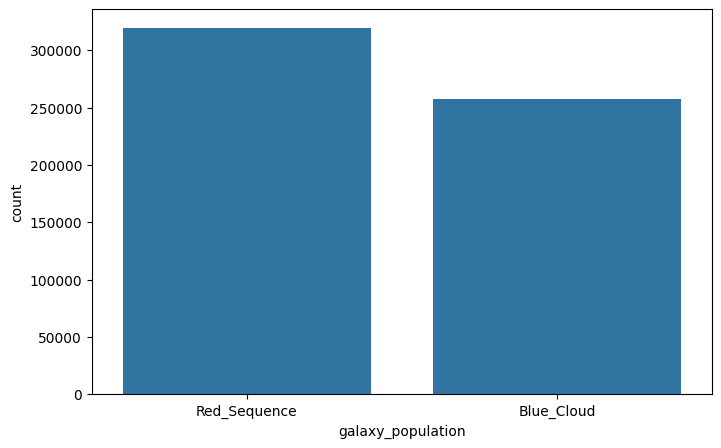

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="galaxy_population"
)

plt.show()

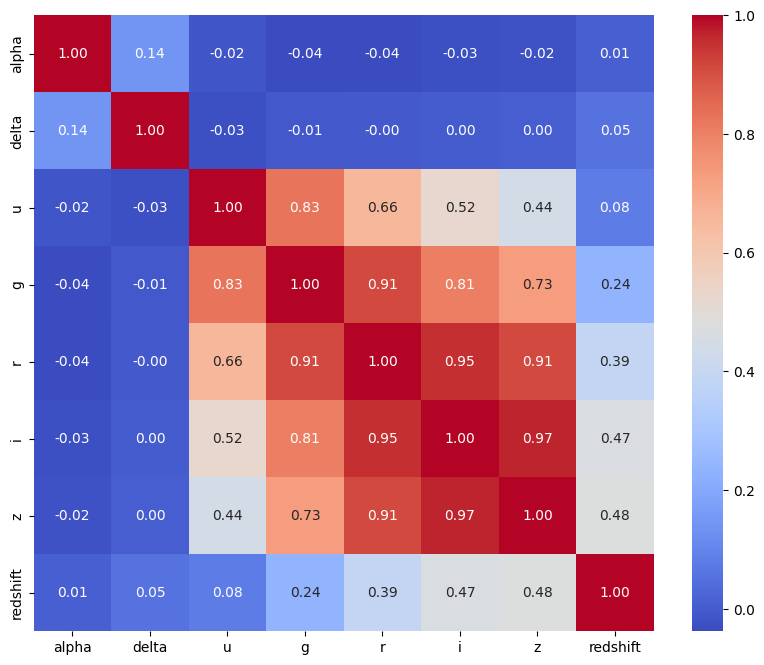

In [18]:
corr = train[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

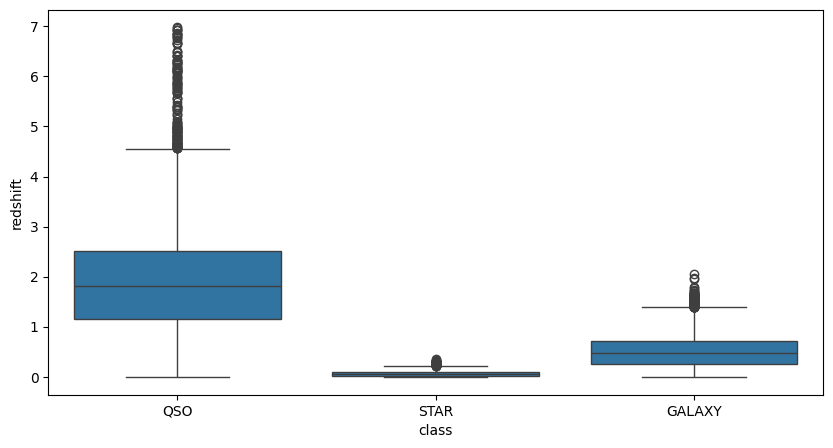

In [19]:
sample_df = train.sample(
    50000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=sample_df,
    x="class",
    y="redshift"
)

plt.show()

In [20]:
for df in [train, test]:

    df["u_g"] = df["u"] - df["g"]

    df["g_r"] = df["g"] - df["r"]

    df["r_i"] = df["r"] - df["i"]

    df["i_z"] = df["i"] - df["z"]

    df["ugri"] = df["u"] - df["i"]

    df["griz"] = df["g"] - df["z"]

    df["redshift_log"] = np.log1p(
        df["redshift"]
    )

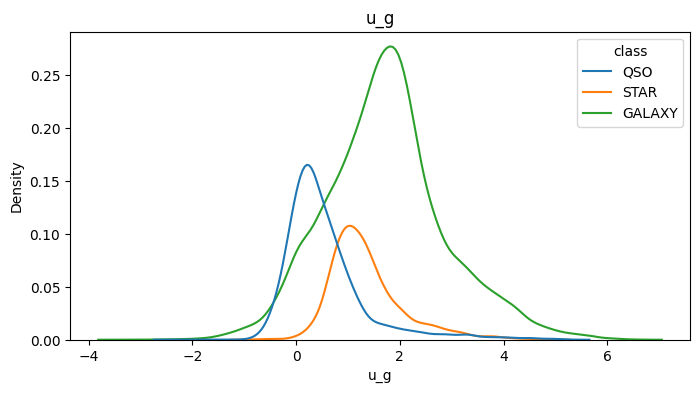

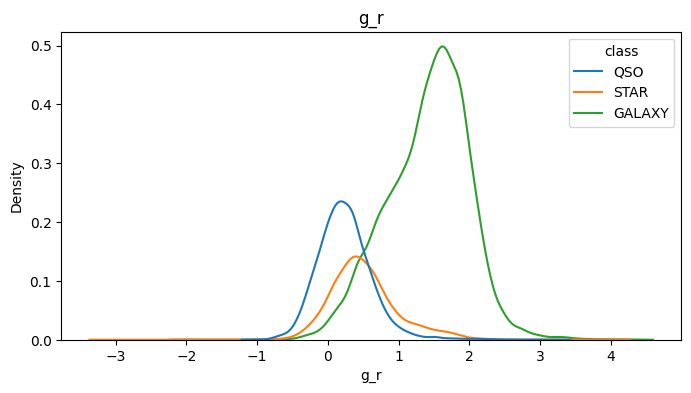

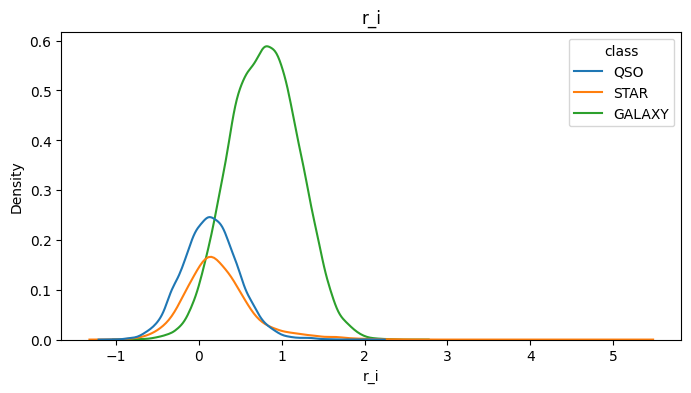

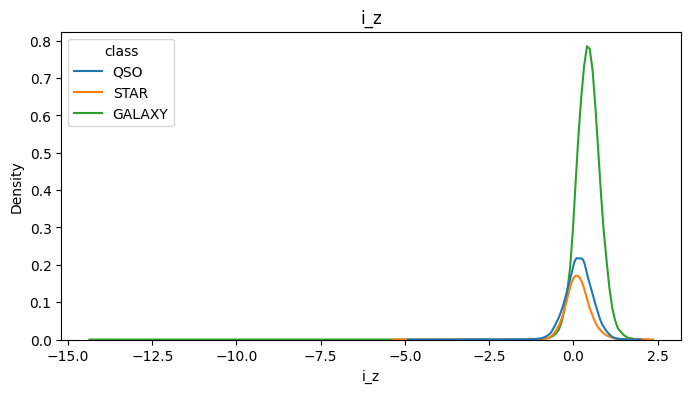

In [21]:
sample_df = train.sample(
    30000,
    random_state=42
)

color_features = [
    "u_g",
    "g_r",
    "r_i",
    "i_z"
]

for col in color_features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=sample_df,
        x=col,
        hue="class"
    )

    plt.title(col)

    plt.show()

In [22]:
pd.crosstab(
    train["spectral_type"],
    train["class"],
    normalize="index"
)

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,0.198490,0.503709,0.297801
G/K,0.567750,0.192739,0.239511
M,0.949559,0.012821,0.037620
O/B,0.082803,0.710836,0.206361


In [23]:
pd.crosstab(
    train["galaxy_population"],
    train["class"],
    normalize="index"
)

class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345106,0.420022,0.234873
Red_Sequence,0.902846,0.027753,0.069401


In [24]:
mi_df = train.copy()

for col in [
    "spectral_type",
    "galaxy_population"
]:

    mi_df[col] = LabelEncoder() \
        .fit_transform(mi_df[col])

y = LabelEncoder() \
    .fit_transform(mi_df["class"])

X = mi_df.drop(
    ["id", "class"],
    axis=1
)

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_result = pd.DataFrame({

    "feature": X.columns,

    "mi_score": mi_scores

}).sort_values(
    "mi_score",
    ascending=False
)

mi_result

,feature,mi_score
16,redshift_log,0.514966
7,redshift,0.514952
15,griz,0.406595
14,ugri,0.376885
8,spectral_type,0.361797
11,g_r,0.320973
9,galaxy_population,0.277876
12,r_i,0.218288
6,z,0.211592
2,u,0.178853


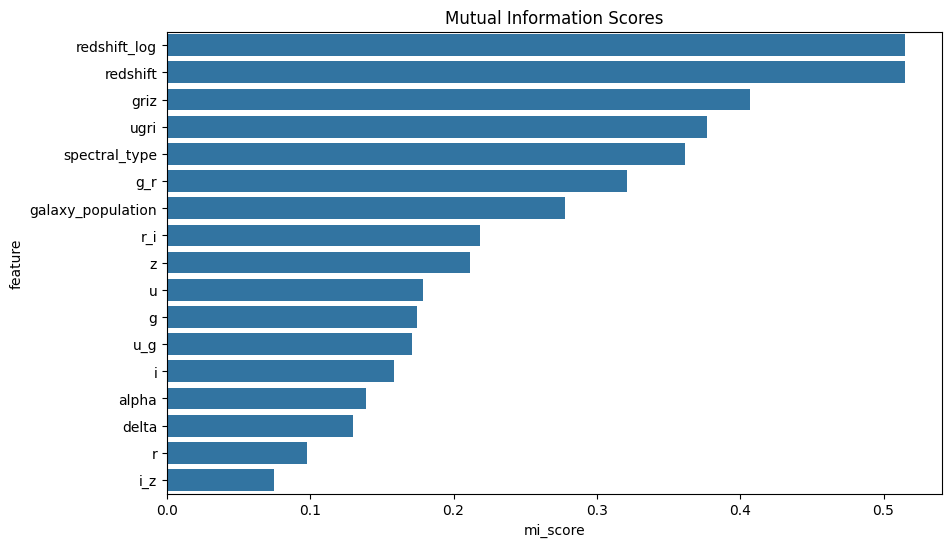

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_result,
    x="mi_score",
    y="feature"
)

plt.title(
    "Mutual Information Scores"
)

plt.show()

In [26]:
eda_report = pd.DataFrame({
    "feature": mi_result["feature"],
    "mi_score": mi_result["mi_score"]
})

eda_report.to_csv(
    "eda_report.csv",
    index=False
)

eda_report.head()

,feature,mi_score
16,redshift_log,0.514966
7,redshift,0.514952
15,griz,0.406595
14,ugri,0.376885
8,spectral_type,0.361797


In [27]:
train.to_csv(
    "train_fe.csv",
    index=False
)

test.to_csv(
    "test_fe.csv",
    index=False
)

print("Files Saved")

Files Saved


In [28]:
from google.colab import files

files.download("train_fe.csv")
files.download("test_fe.csv")
files.download("eda_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import os
import matplotlib.pyplot as plt

# Create plots directory
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"Saving plots to: {PLOT_DIR}/")

Saving plots to: plots/


In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="class"
)

plt.title("Target Distribution")

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=sample_df,
    x="class",
    y="redshift"
)

plt.title("Redshift by Class")

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/redshift_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [33]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=train,
    x="spectral_type",
    order=train["spectral_type"].value_counts().index
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/spectral_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="galaxy_population"
)

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/galaxy_population_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_result,
    x="mi_score",
    y="feature"
)

plt.title("Mutual Information Scores")

plt.tight_layout()

plt.savefig(
    f"{PLOT_DIR}/mutual_information_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [36]:
for col in color_features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=train.sample(30000, random_state=42),
        x=col,
        hue="class"
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        f"{PLOT_DIR}/{col}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

In [37]:
import shutil

shutil.make_archive(
    "eda_plots",
    "zip",
    PLOT_DIR
)

print("Created eda_plots.zip")

Created eda_plots.zip


In [38]:
from google.colab import files

files.download("eda_plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>